# Multi-Class Animal Classification
## Classifying Elephant, Tiger, and Fox

#### Import Required Libraries

In [31]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
import torchvision.models as models

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Used device: {device}")

Used device: cpu


#### Set Data Root Path

In [32]:
DATA_ROOT = "/info/etu/m2/s2405959/deepLearning/L3_project/Tiger-Fox-Elephant"

#### Explore the Dataset

In [33]:
def explore_dataset(data_root):
    animals = ['elephant', 'tiger', 'fox']
    stats = {}
    for animal in animals:
        pos_dir = os.path.join(data_root, animal)
        pos_images = [f for f in os.listdir(pos_dir) if f.endswith(('.jpg'))]
        
        pos_gen_dir = os.path.join(data_root, f"{animal}_generated")
        pos_gen_images = []
        if os.path.exists(pos_gen_dir):
            pos_gen_images = [f for f in os.listdir(pos_gen_dir) if f.endswith(('.jpg'))]
        
        total_pos = len(pos_images) + len(pos_gen_images)
        stats[animal] = {'original': len(pos_images), 'generated': len(pos_gen_images), 'total': total_pos}
        print(f"{animal.upper()}: {len(pos_images)} original, {len(pos_gen_images)} generated, {total_pos} total")
    return stats

explore_dataset(DATA_ROOT)

ELEPHANT: 100 original, 200 generated, 300 total
TIGER: 100 original, 200 generated, 300 total
FOX: 100 original, 200 generated, 300 total


{'elephant': {'original': 100, 'generated': 200, 'total': 300},
 'tiger': {'original': 100, 'generated': 200, 'total': 300},
 'fox': {'original': 100, 'generated': 200, 'total': 300}}

#### View Sample Images from Each Class

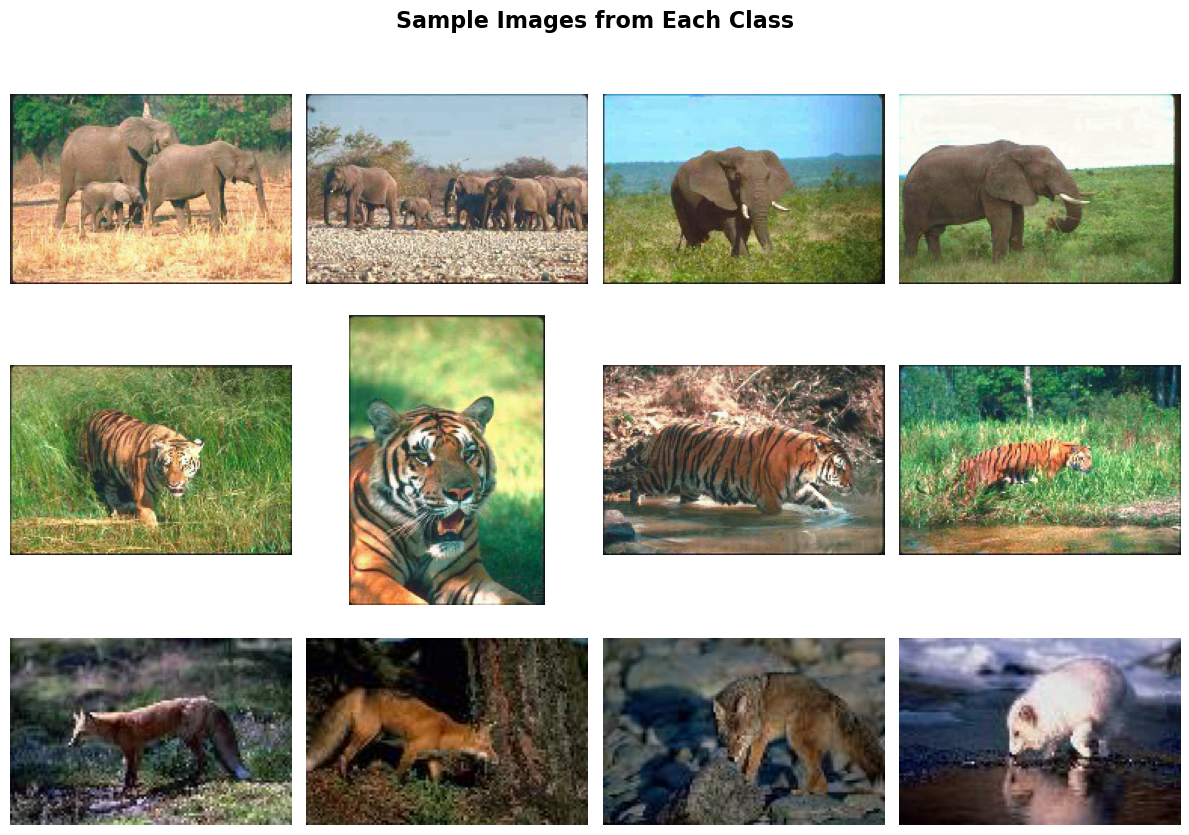

In [34]:
animals = ['elephant', 'tiger', 'fox']
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
fig.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold')

for row, animal in enumerate(animals):
    pos_dir = os.path.join(DATA_ROOT, animal)
    pos_imgs = [os.path.join(pos_dir, f) for f in os.listdir(pos_dir) if f.endswith('.jpg')][:4]
    
    for col, img_path in enumerate(pos_imgs):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(animal.capitalize(), fontsize=12, fontweight='bold', rotation=0, ha='right', va='center')

plt.tight_layout()
plt.show()

#### Multi-Class Dataset Class

In [35]:
class AnimalMultiClassDataset(Dataset):

    def __init__(self, data_root, img_size=(128,128)):
        self.img_size = img_size
        self.image_paths = []
        self.labels = []
        
        animals = ['elephant', 'tiger', 'fox']
        
        for class_idx, animal in enumerate(animals):
            pos_dir = os.path.join(data_root, animal)
            pos_images = [os.path.join(pos_dir, i) for i in os.listdir(pos_dir) if i.endswith('.jpg')]
            self.image_paths.extend(pos_images)
            self.labels.extend([class_idx] * len(pos_images))
            
            pos_gen_dir = os.path.join(data_root, f"{animal}_generated")
            if os.path.exists(pos_gen_dir):
                pos_gen_images = [os.path.join(pos_gen_dir, i) for i in os.listdir(pos_gen_dir) if i.endswith('.jpg')]
                self.image_paths.extend(pos_gen_images)
                self.labels.extend([class_idx] * len(pos_gen_images))
        
        print(f"Total images loaded: {len(self.image_paths)}")
        print(f"Elephant (0): {self.labels.count(0)}, Tiger (1): {self.labels.count(1)}, Fox (2): {self.labels.count(2)}")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, self.img_size)
        image = image.astype(np.float32) / 255.0
        image = torch.from_numpy(image).permute(2, 0, 1)
        
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

#### Multi-Class CNN Model (Basic - Without Transfer Learning)

In [36]:
class CNN_model_MultiClass(nn.Module):
    def __init__(self, img_size=128, num_classes=3):
        super(CNN_model_MultiClass, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.dropout1 = nn.Dropout2d(0.4)
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten_size = 16 * (img_size // 2) * (img_size // 2)
        self.fc1 = nn.Linear(self.flatten_size, 64)
        self.dropout2 = nn.Dropout(0.6)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.dropout1(x)
        x = self.maxpool(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

#### Training Function for Basic CNN Model

In [37]:
def train_basic_multiclass(model, train_loader, val_loader, epochs, checkpoint_dir='checkpoints'):
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    patience_counter = 0
    early_stop_patience = 15
    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
        
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
        
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        train_accuracy = 100 * correct_train / total_train
        val_accuracy = 100 * correct_val / total_val

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        scheduler.step(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}]")
            print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2f}%")
            print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
                'train_accuracy': train_accuracy,
                'val_accuracy': val_accuracy
            }
            torch.save(checkpoint, os.path.join(checkpoint_dir, 'multiclass_basic_best.pth'))
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                print(f"Early stopping at epoch {epoch+1}")
                break 

    return train_losses, val_losses, train_accuracies, val_accuracies

#### Train Basic Multi-Class Model

Total images loaded: 900
Elephant (0): 300, Tiger (1): 300, Fox (2): 300
training Basic Multi-class CNN Model (without transfer learning)...


Epoch [10/80]
  Train Loss: 0.2398 | Train Acc: 90.97%
  Val Loss: 0.2272 | Val Acc: 91.67%
Epoch [20/80]
  Train Loss: 0.1087 | Train Acc: 95.97%
  Val Loss: 0.2342 | Val Acc: 92.78%
Epoch [20/80]
  Train Loss: 0.1087 | Train Acc: 95.97%
  Val Loss: 0.2342 | Val Acc: 92.78%
Epoch [30/80]
  Train Loss: 0.0953 | Train Acc: 97.36%
  Val Loss: 0.0967 | Val Acc: 97.78%
Epoch [30/80]
  Train Loss: 0.0953 | Train Acc: 97.36%
  Val Loss: 0.0967 | Val Acc: 97.78%
Epoch [40/80]
  Train Loss: 0.0907 | Train Acc: 97.22%
  Val Loss: 0.0786 | Val Acc: 97.22%
Epoch [40/80]
  Train Loss: 0.0907 | Train Acc: 97.22%
  Val Loss: 0.0786 | Val Acc: 97.22%
Epoch [50/80]
  Train Loss: 0.0288 | Train Acc: 99.03%
  Val Loss: 0.0962 | Val Acc: 98.33%
Epoch [50/80]
  Train Loss: 0.0288 | Train Acc: 99.03%
  Val Loss: 0.0962 | Val Acc: 98.33%
Epoch [60/80]
  Train Loss: 0.0210 | Train Acc: 99.31%
  Val Loss: 0.0488 | Val Acc: 98.89%
Epoch [60/80]
  Train Loss: 0.0210 | Train Acc: 99.31%
  Val Loss: 0.0488 | Val 

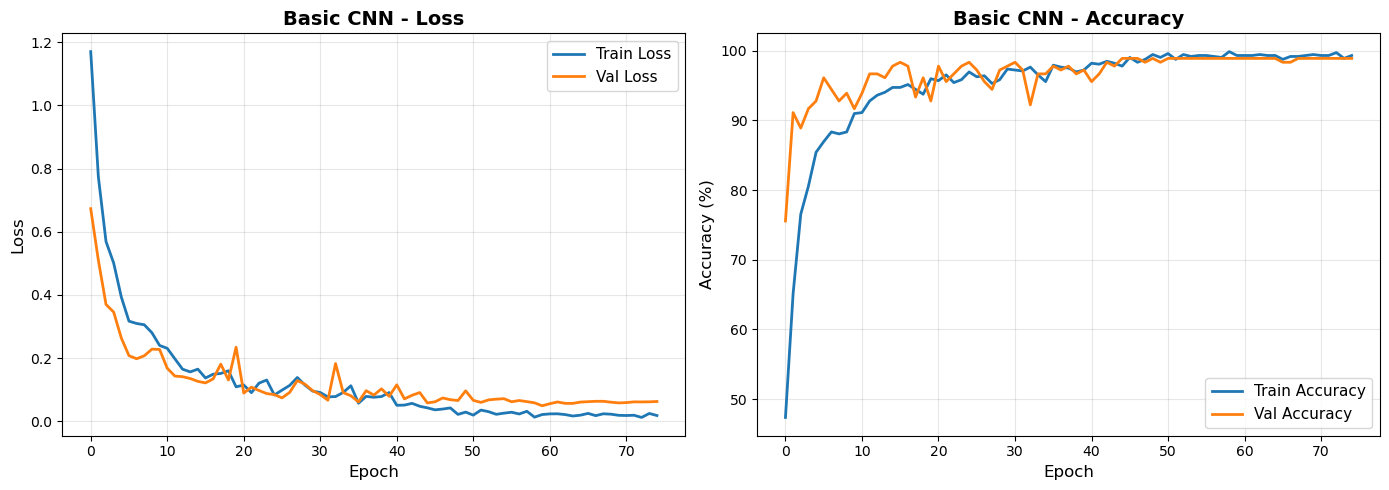


Basic Model, Best Val Accuracy: 98.89%


In [38]:
BATCH_SIZE = 16
EPOCHS = 80
IMG_SIZE = 128

multiclass_dataset = AnimalMultiClassDataset(DATA_ROOT, img_size=(IMG_SIZE, IMG_SIZE))

train_idx, val_idx = train_test_split(
    range(len(multiclass_dataset)), 
    test_size=0.2, 
    random_state=42, 
    stratify=multiclass_dataset.labels
)

train_subset = torch.utils.data.Subset(multiclass_dataset, train_idx)
val_subset = torch.utils.data.Subset(multiclass_dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

print("training Basic Multi-class CNN Model (without transfer learning)...")
model_basic = CNN_model_MultiClass(img_size=IMG_SIZE, num_classes=3).to(device)

train_losses_basic, val_losses_basic, train_accs_basic, val_accs_basic = train_basic_multiclass(
    model_basic, train_loader, val_loader, EPOCHS
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses_basic, label='Train Loss', linewidth=2)
ax1.plot(val_losses_basic, label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Basic CNN - Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs_basic, label='Train Accuracy', linewidth=2)
ax2.plot(val_accs_basic, label='Val Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Basic CNN - Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBasic Model, Best Val Accuracy: {max(val_accs_basic):.2f}%")

#### Multi-Class ResNet50 Model with Transfer Learning

In [39]:
class CNN_model_ResNet50_MultiClass(nn.Module):
    def __init__(self, num_classes=3):
        super(CNN_model_ResNet50_MultiClass, self).__init__()
        self.resnet = models.resnet50(pretrained=True)
        
        for param in self.resnet.parameters():
            param.requires_grad = False
        
        num_features = self.resnet.fc.in_features
        
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

#### Training Function for Transfer Learning Model (ResNet50)

In [40]:
def train_transfer_multiclass(model, train_loader, val_loader, epochs, checkpoint_dir='checkpoints'):
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    patience_counter = 0
    early_stop_patience = 15
    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
        
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
        
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        train_accuracy = 100 * correct_train / total_train
        val_accuracy = 100 * correct_val / total_val

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        scheduler.step(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}]")
            print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2f}%")
            print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
                'train_accuracy': train_accuracy,
                'val_accuracy': val_accuracy
            }
            torch.save(checkpoint, os.path.join(checkpoint_dir, 'multiclass_transfer_best.pth'))
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                print(f"Early stopping at epoch {epoch+1}")
                break 

    return train_losses, val_losses, train_accuracies, val_accuracies

#### Train Transfer Learning Model (ResNet50)


Training Multi-class CNN Model with Transfer Learning (ResNet50)...


/info/etu/m2/s2405959/miniconda3/envs/deeplearning/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/info/etu/m2/s2405959/miniconda3/envs/deeplearning/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [10/50]
  Train Loss: 0.1378 | Train Acc: 95.42%
  Val Loss: 0.0524 | Val Acc: 100.00%
Epoch [20/50]
  Train Loss: 0.0852 | Train Acc: 97.08%
  Val Loss: 0.0234 | Val Acc: 100.00%
Epoch [20/50]
  Train Loss: 0.0852 | Train Acc: 97.08%
  Val Loss: 0.0234 | Val Acc: 100.00%
Epoch [30/50]
  Train Loss: 0.0557 | Train Acc: 98.33%
  Val Loss: 0.0311 | Val Acc: 100.00%
Epoch [30/50]
  Train Loss: 0.0557 | Train Acc: 98.33%
  Val Loss: 0.0311 | Val Acc: 100.00%
Epoch [40/50]
  Train Loss: 0.0831 | Train Acc: 97.22%
  Val Loss: 0.0141 | Val Acc: 99.44%
Epoch [40/50]
  Train Loss: 0.0831 | Train Acc: 97.22%
  Val Loss: 0.0141 | Val Acc: 99.44%
Epoch [50/50]
  Train Loss: 0.0531 | Train Acc: 98.47%
  Val Loss: 0.0070 | Val Acc: 100.00%
Epoch [50/50]
  Train Loss: 0.0531 | Train Acc: 98.47%
  Val Loss: 0.0070 | Val Acc: 100.00%


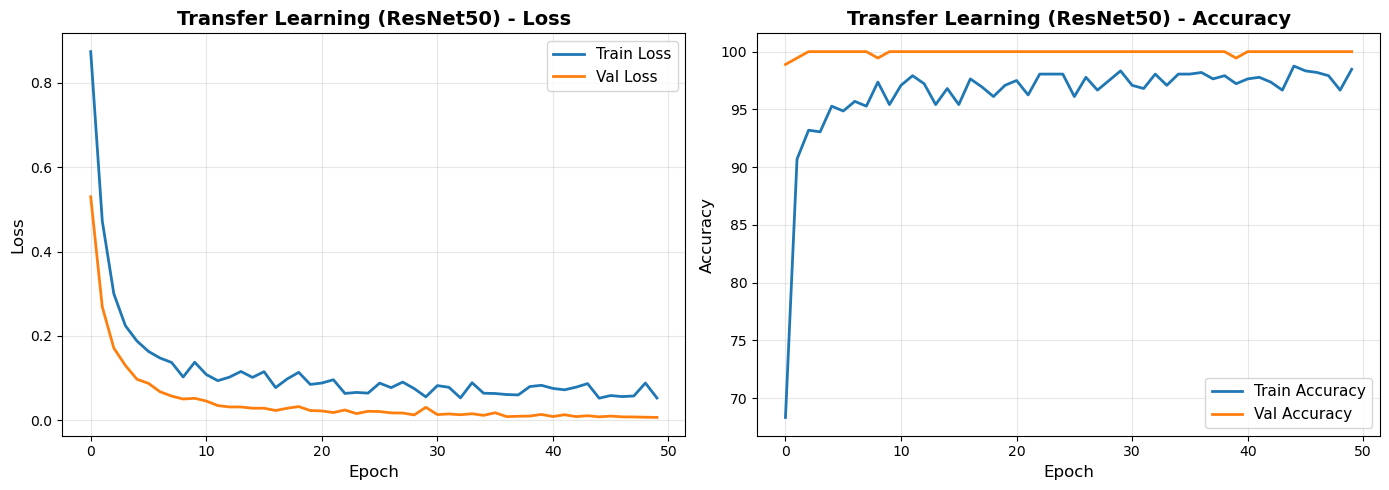


Transfer Learning Model  Best Validation Accuracy: 100.00%


In [41]:
BATCH_SIZE = 16
EPOCHS = 50
IMG_SIZE = 128

print("\nTraining Multi-class CNN Model with Transfer Learning (ResNet50)...")
model_transfer = CNN_model_ResNet50_MultiClass(num_classes=3).to(device)

train_losses_transfer, val_losses_transfer, train_accs_transfer, val_accs_transfer = train_transfer_multiclass(
    model_transfer, train_loader, val_loader, EPOCHS
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses_transfer, label='Train Loss', linewidth=2)
ax1.plot(val_losses_transfer, label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Transfer Learning (ResNet50) - Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs_transfer, label='Train Accuracy', linewidth=2)
ax2.plot(val_accs_transfer, label='Val Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Transfer Learning (ResNet50) - Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTransfer Learning Model  Best Validation Accuracy: {max(val_accs_transfer):.2f}%")

#### Compare Both Models

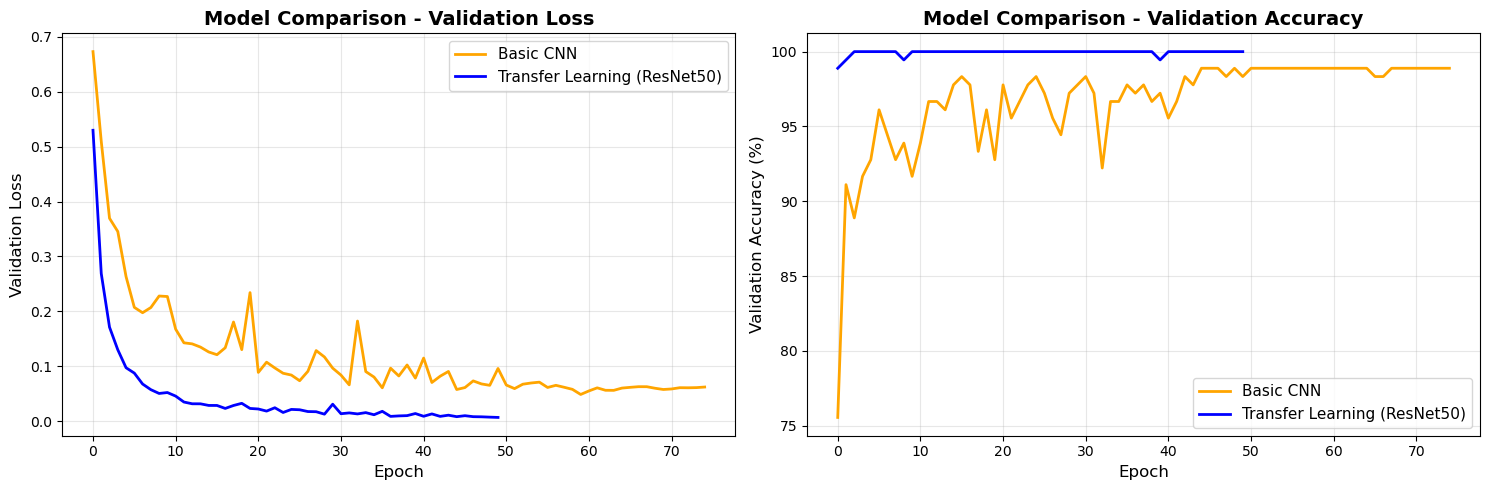

Basic CNN Model:
Best Validation Accuracy: 98.89
Final Validation Loss: 0.0624

Transfer Learning (ResNet50) Model:
Best Validation Accuracy: 100.00
Final Validation Loss: 0.0070

Improvement: 1.11 better accuracy


In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(val_losses_basic, label='Basic CNN', linewidth=2, color='orange')
ax1.plot(val_losses_transfer, label='Transfer Learning (ResNet50)', linewidth=2, color='blue')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Validation Loss', fontsize=12)
ax1.set_title('Model Comparison - Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(val_accs_basic, label='Basic CNN', linewidth=2, color='orange')
ax2.plot(val_accs_transfer, label='Transfer Learning (ResNet50)', linewidth=2, color='blue')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax2.set_title('Model Comparison - Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



print(f"Basic CNN Model:")
print(f"Best Validation Accuracy: {max(val_accs_basic):.2f}")
print(f"Final Validation Loss: {val_losses_basic[-1]:.4f}")
print()
print(f"Transfer Learning (ResNet50) Model:")
print(f"Best Validation Accuracy: {max(val_accs_transfer):.2f}")
print(f"Final Validation Loss: {val_losses_transfer[-1]:.4f}")
print()
print(f"Improvement: {max(val_accs_transfer) - max(val_accs_basic):.2f} better accuracy")


#### Test Multi-Class Model with Resnet

In [43]:
test_dir = '/info/etu/m2/s2405959/deepLearning/L3_project/test_samples'
test_images = sorted([f for f in os.listdir(test_dir) if f.endswith('.jpg')])

model_multiclass = CNN_model_ResNet50_MultiClass(num_classes=3).to(device)
checkpoint = torch.load('checkpoints/multiclass_transfer_best.pth', map_location=device)
model_multiclass.load_state_dict(checkpoint['model_state_dict'])
model_multiclass.eval()

class_names = ['Elephant', 'Tiger', 'Fox']


for img_name in test_images:
    true_animal = None
    if 'elephant' in img_name.lower() or 'elephen' in img_name.lower():
        true_animal = 'Elephant'
    elif 'fox' in img_name.lower() or 'for' in img_name.lower():
        true_animal = 'Fox'
    elif 'tiger' in img_name.lower():
        true_animal = 'Tiger'
    
    img_path = os.path.join(test_dir, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_tensor = torch.from_numpy(
        cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
    ).permute(2, 0, 1).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model_multiclass(img_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        predicted_class = torch.argmax(probabilities).item()
        confidence = probabilities[predicted_class].item()
    
    predicted_animal = class_names[predicted_class]
    
    probs_str = " | ".join([f"{name}: {probabilities[i].item():.2%}" for i, name in enumerate(class_names)])
    
    correct = "correct" if predicted_animal == true_animal else "false"
    print(f"{img_name:25} | True: {true_animal:8} | Pred: {predicted_animal:8} ({confidence:.2%}) {correct}")
    print(f"{'':27} | {probs_str}")
    print("-" * 70)

elephen_real.jpg          | True: Elephant | Pred: Elephant (99.96%) correct
                            | Elephant: 99.96% | Tiger: 0.00% | Fox: 0.04%
----------------------------------------------------------------------
elephent_fake.jpg         | True: Elephant | Pred: Elephant (97.01%) correct
                            | Elephant: 97.01% | Tiger: 1.31% | Fox: 1.68%
----------------------------------------------------------------------
fox_fake.jpg              | True: Fox      | Pred: Elephant (95.85%) false
                            | Elephant: 95.85% | Tiger: 0.53% | Fox: 3.62%
----------------------------------------------------------------------
fox_real.jpg              | True: Fox      | Pred: Fox      (99.96%) correct
                            | Elephant: 0.02% | Tiger: 0.01% | Fox: 99.96%
----------------------------------------------------------------------
tiger_fake.jpg            | True: Tiger    | Pred: Elephant (72.86%) false
                            | Eleph